<a href="https://colab.research.google.com/github/wr2401/codelearning/blob/main/BP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 如果没有报告 tensorflow 版本，请取消注释“#”以使用 pip 安装 tensorflow 包
!pip install tensorflow

!pip install scikit-learn

In [ ]:
# 需要 Python 版本 >= 3.5
! python  --version
import tensorflow
import matplotlib.pyplot as plt
print('tensorflow: %s' % tensorflow.__version__)
# 需要 Scikit-Learn >=0.30 版本
import sklearn
print('sckitlearn: %s' % sklearn.__version__)

Python 3.12.12
tensorflow: 2.19.0
sckitlearn: 1.6.1


In [ ]:
import tensorflow
from tensorflow import keras
from keras.datasets import mnist
from keras.utils import *
#from keras.mobels import Mobel
import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
def sigmoid(z):
  return 1.0/(1.0+np.exp(-z))

In [ ]:
def sigmoid_prime(z):
  return sigmoid(z)*(1-sigmoid(z))

In [ ]:
def plot_accuracies(accuracies):
  plt.plot(accuracies,'o-')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.grid(True)
  plt.show()

In [ ]:
class Network(object):
  def __init__(self,sizes):
    self.num_layers=len(sizes)
    self.sizes=sizes
    self.test_accuracies=[]
    #randn:生成服从标准正态分布的随机数
    self.weights=[np.random.randn(y,x) for x,y in zip(sizes[:-1],sizes[1:])]
    self.biases=[np.random.randn(y,1) for y in sizes[1:]]
  def feedforward(self,a):
    for b,w in zip(self.biases,self.weights):
      a=sigmoid(np.dot(w,a)+b)
    return a
  def SGD(self,training_data,epochs,mini_batch_size,eta,test_data=None):
    if test_data:n_test=len(test_data)
    n=len(training_data)
    for j in range(epochs):
      random.shuffle(training_data)
      mini_batches=[training_data[k:k+mini_batch_size] for k in range(0,n,mini_batch_size)]
      for mini_batch in mini_batches:
        self.update_mini_batch(mini_batch,eta)
      if test_data:
        accuracy=self.evaluate(test_data)
        self.test_accuracies.append(accuracy)
        print("Epoch{0}:{1}/{2}".format(j,accuracy,n_test))
      else:
        print("Epoch{0} complete".format(j))
  def update_mini_batch(self,mini_batch,eta):
    nabla_b=[np.zeros(b.shape) for b in self.biases]
    nabla_w=[np.zeros(w.shape) for w in self.weights]
    for x,y in mini_batch:
      delta_nabla_b,delta_nabla_w=self.backprop(x,y)
      #print("nabla_w shapes:", [nw.shape for nw in nabla_w])
      #print("delta_nabla_w shapes:", [dnw.shape for dnw in delta_nabla_w])
      nabla_b=[nb+dnb for nb,dnb in zip(nabla_b,delta_nabla_b)]
      nabla_w=[nw+dnw for nw,dnw in zip(nabla_w,delta_nabla_w)]
    self.weights=[w-(eta/len(mini_batch))*nw for w,nw in zip(self.weights,nabla_w)]
    self.biases=[b-(eta/len(mini_batch))*nb for b,nb in zip(self.biases,nabla_b)]
  def backprop(self,x,y):
    nabla_b=[np.zeros(b.shape) for b in self.biases]
    nabla_w=[np.zeros(w.shape) for w in self.weights]
    activation=x
    activations=[x]
    zs=[]
    for b,w in zip(self.biases,self.weights):
      z=np.dot(w,activation)+b
      zs.append(z)
      activation=sigmoid(z)
      activations.append(activation)
    delta=self.cost_derivative(activations[-1],y)*sigmoid_prime(zs[-1])
    nabla_b[-1]=delta
    nabla_w[-1]=np.dot(delta,activations[-2].transpose())
    for layer in range(2,self.num_layers):
      delta=np.dot(self.weights[-layer+1].transpose(),delta)*sigmoid_prime(zs[-layer])
      nabla_b[-layer]=delta
      nabla_w[-layer]=np.dot(delta,activations[-layer-1].transpose())
    return (nabla_b,nabla_w)
  def evaluate(self,test_data):
    test_results=[(np.argmax(self.feedforward(x)),y) for (x,y) in test_data]
    return sum(int(x==y) for (x,y) in test_results)
  def cost_derivative(self,predict,y):
    return (predict-y)

Epoch0:9154/10000
Epoch1:9275/10000
Epoch2:9357/10000
Epoch3:9363/10000
Epoch4:9438/10000
Epoch5:9443/10000
Epoch6:9448/10000
Epoch7:9491/10000
Epoch8:9460/10000
Epoch9:9478/10000
Epoch10:9490/10000
Epoch11:9488/10000
Epoch12:9494/10000
Epoch13:9481/10000
Epoch14:9514/10000
Epoch15:9495/10000
Epoch16:9511/10000
Epoch17:9512/10000
Epoch18:9513/10000
Epoch19:9515/10000
Epoch20:9502/10000
Epoch21:9501/10000
Epoch22:9515/10000
Epoch23:9552/10000
Epoch24:9521/10000
Epoch25:9526/10000
Epoch26:9525/10000
Epoch27:9535/10000
Epoch28:9544/10000
Epoch29:9542/10000
Epoch30:9537/10000
Epoch31:9547/10000
Epoch32:9529/10000
Epoch33:9551/10000
Epoch34:9549/10000


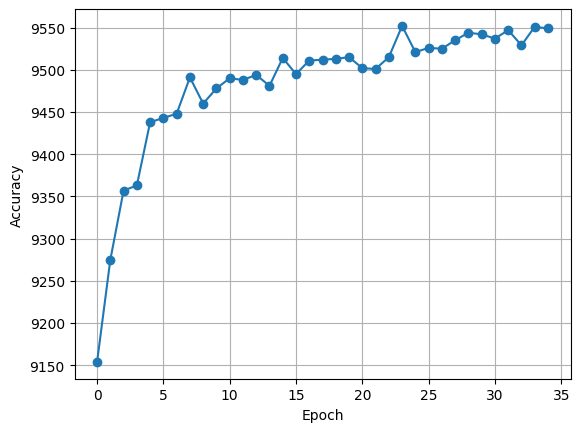

In [ ]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train=[x_train[i].reshape(784,1)/255 for i in range(x_train.shape[0])]
y_train=to_categorical(y_train,10)
#print(y_train[0].shape,y_train[0])
y_train=[y_train[i].reshape(10,1) for i in range(y_train.shape[0])]
training_data=list(zip(x_train,y_train))
x_test=[x_test[i].reshape(784,1)/255 for i in range(x_test.shape[0])]
test_data=list(zip(x_test,y_test))
net=Network([784,35,10])
net.SGD(training_data,35,10,3.0,test_data=test_data)
plot_accuracies(net.test_accuracies)